In [2]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"

import scipy

import pandas as pd
import numpy as np
import import_ipynb
import matplotlib.pyplot as plt
import seaborn as sns
import Preprocessing as pps
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, RandomizedSearchCV, KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import joblib

In [3]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [4]:
data = pd.read_csv(r"../data/dataset.csv")

In [5]:
data_clean_2=pps.clean_data_2(data)
print(data.shape)
print(data_clean_2.shape)

(768, 9)
(708, 11)


In [6]:
data_clean_2.head()

,index_tab,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insuline_bool,SkinThickness_bool
0,0,6,148,72,35,0,33.6,0.627,50,0,1
1,1,1,85,66,29,0,26.6,0.351,31,0,1
2,2,8,183,64,0,0,23.3,0.672,32,0,0
3,3,1,89,66,23,94,28.1,0.167,21,1,1
5,5,5,116,74,0,0,25.6,0.201,30,0,0


In [7]:
colonnes_cluster=['Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']

Appliquer un scaler sur les données choisies

In [8]:
X=data_clean_2[colonnes_cluster]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

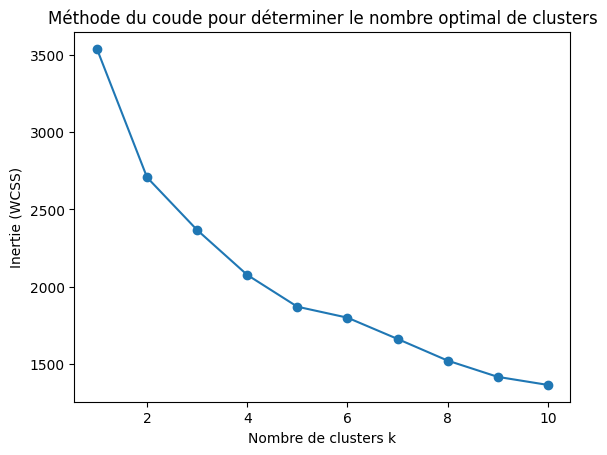

In [9]:

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Tracer la courbe du coude
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (WCSS)')
plt.title('Méthode du coude pour déterminer le nombre optimal de clusters')
plt.show()

Selon le graphique nous avons  clusters

Determination des clusters

In [10]:
k = 2

# Créez le modèle KMeans et entraînez-le sur les données
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(X_scaled)

# Récupérez les labels (attribution des clusters pour chaque ligne)
labels = kmeans.labels_

# Ajoutez les labels au DataFrame original (nouvelle colonne 'cluster')
data_clean_2['cluster'] = labels

# Affichez un aperçu
print(data_clean_2.head())

   index_tab  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
0          0            6      148             72             35        0   
1          1            1       85             66             29        0   
2          2            8      183             64              0        0   
3          3            1       89             66             23       94   
5          5            5      116             74              0        0   

    BMI  DiabetesPedigreeFunction  Age  Insuline_bool  SkinThickness_bool  \
0  33.6                     0.627   50              0                   1   
1  26.6                     0.351   31              0                   1   
2  23.3                     0.672   32              0                   0   
3  28.1                     0.167   21              1                   1   
5  25.6                     0.201   30              0                   0   

   cluster  
0        0  
1        1  
2        0  
3        1  
5        

PCA

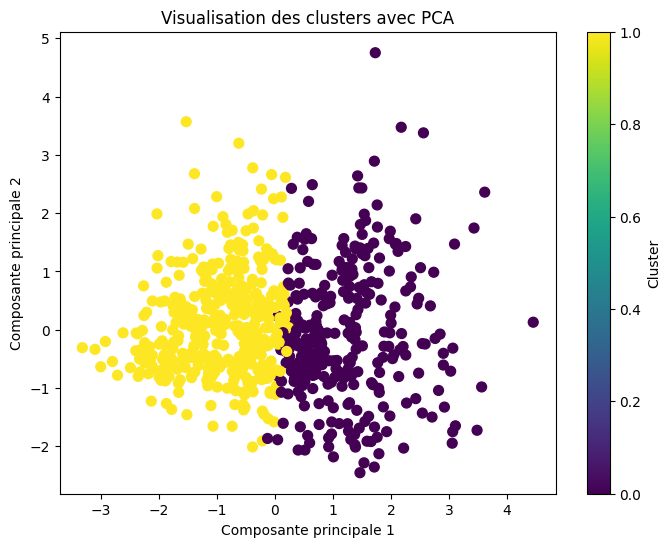

In [11]:
# Réduction à 2 dimensions avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tracé des points colorés par cluster
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title('Visualisation des clusters avec PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()


In [12]:
# Afficher la part de variance expliquée par PC1 et PC2
print("Variance expliquée par PC1 : {:.2%}".format(pca.explained_variance_ratio_[0]))
print("Variance expliquée par PC2 : {:.2%}".format(pca.explained_variance_ratio_[1]))
print("Variance expliquée cumulée : {:.2%}".format(sum(pca.explained_variance_ratio_)))

Variance expliquée par PC1 : 34.79%
Variance expliquée par PC2 : 20.74%
Variance expliquée cumulée : 55.53%


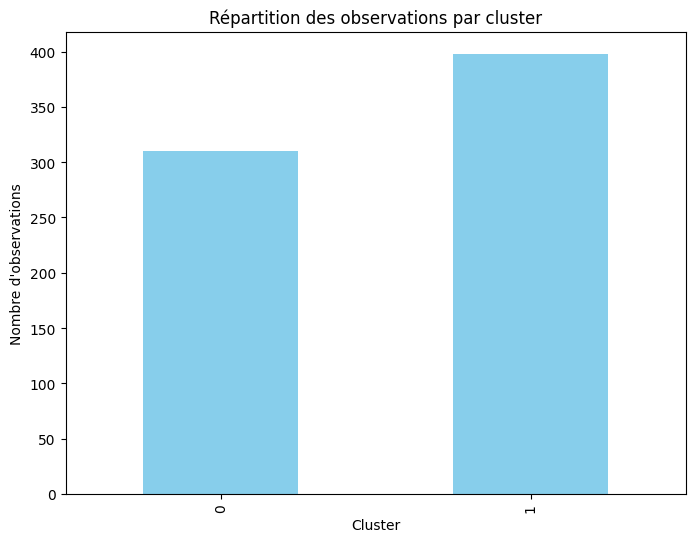

cluster
0    310
1    398
Name: count, dtype: int64


In [13]:
cluster_counts = data_clean_2['cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Cluster')
plt.ylabel("Nombre d'observations")
plt.title('Répartition des observations par cluster')
plt.show()
print(cluster_counts)

Calcul des moyennes pour chaque cluster

In [14]:
moyennes_par_cluster = data_clean_2.groupby('cluster').agg(
    Mean_Glucose=('Glucose', 'mean'),
    Mean_BloodPressure=('BloodPressure', 'mean'),
    Mean_BMI=('BMI', 'mean'),
    Mean_DPF=('DiabetesPedigreeFunction', 'mean'),
    Mean_Age=('Age', 'mean')
)
print(moyennes_par_cluster)

         Mean_Glucose  Mean_BloodPressure   Mean_BMI  Mean_DPF   Mean_Age
cluster                                                                  
0          141.858065           79.709677  35.264194  0.507774  41.261290
1          105.929648           66.804020  29.855779  0.431000  27.351759


Il semble que le cluster 0 est celui à risque de diabéte et le cluster 1 celui à faible risque

## Entrainement des modèles

Précision (Precision)
La précision est une métrique qui mesure la proportion d'identifications positives qui étaient réellement correctes. Elle est calculée en divisant le nombre de vrais positifs par la somme des vrais positifs et des faux positifs (VP / (VP + FP)). Une précision élevée indique que le modèle a un faible taux de faux positifs.

Rappel (Recall)
Le rappel, aussi appelé sensibilité, mesure la proportion de positifs réels qui ont été correctement identifiés par le modèle. Il est calculé en divisant le nombre de vrais positifs par la somme des vrais positifs et des faux négatifs (VP / (VP + FN)). Un rappel élevé signifie que le modèle a un faible taux de faux négatifs.

F1 score
Le F1-score (ou score F1) est une métrique d'évaluation des modèles de classification qui combine la précision (precision) et le rappel (recall) en une seule valeur. Il est particulièrement utile dans les cas où les classes sont déséquilibrées.

In [15]:
X=data_clean_2[colonnes_cluster]
y=data_clean_2['cluster']

X_train, X_test, y_train, y_test=train_test_split(X, y,test_size=0.20,random_state=42,stratify=y )
y_train=y_train
X_train.shape, y_train.shape

class_names = sorted(y.unique().astype(str))
print("Classes dans la cible : ", class_names)

Classes dans la cible :  [np.str_('0'), np.str_('1')]


In [16]:
#Afficher la distribution des classes dans le training set
class_distribution = y_train.value_counts(normalize=True)
print("\nDistribution des classes dans le training set:")
for class_label, proportion in class_distribution.items():
    risk_level = "Faible risque" if class_label == 1 else "Haut risque"
    print(f"   {risk_level}: {proportion:.3f} ({y_train.value_counts()[class_label]} échantillons)")


Distribution des classes dans le training set:
   Faible risque: 0.562 (318 échantillons)
   Haut risque: 0.438 (248 échantillons)


In [17]:
#Définir les pipelines des modèles

models = {
    "Random Forest": Pipeline([
        ('ros', RandomOverSampler(random_state=42)),
        ('clf', RandomForestClassifier(random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ('ros', RandomOverSampler(random_state=42)),
        ('clf', GradientBoostingClassifier(random_state=42))
    ]),
    "SVM": Pipeline([
        ('ros', RandomOverSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', SVC(random_state=42))
    ]),
    "Régression Logistique": Pipeline([
        ('ros', RandomOverSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42, max_iter=200))
    ]),
}

In [18]:
# Entraînement, prédiction et évaluation dans une boucle

for name, pipeline in models.items():
    print(f"\n==================== {name} ====================")
    
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédictions sur le test
    y_pred = pipeline.predict(X_test)
    
    # Cross-validation sur le train avec pipeline complet
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
    print(f"Cross-validation F1-score (moyenne) : {cv_scores.mean():.3f}")
    print(f"Cross-validation F1-score (écart-type) : {cv_scores.std():.3f}")
    
    # Matrice de confusion
    print("\nMatrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    
    # Rapport de classification complet
    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred, target_names=class_names))


==================== Random Forest ====================
Cross-validation F1-score (moyenne) : 0.945
Cross-validation F1-score (écart-type) : 0.025

Matrice de confusion :
[[60  2]
 [ 2 78]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        62
           1       0.97      0.97      0.97        80

    accuracy                           0.97       142
   macro avg       0.97      0.97      0.97       142
weighted avg       0.97      0.97      0.97       142


==================== Gradient Boosting ====================
Cross-validation F1-score (moyenne) : 0.940
Cross-validation F1-score (écart-type) : 0.025

Matrice de confusion :
[[58  4]
 [ 2 78]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        62
           1       0.95      0.97      0.96        80

    accuracy                           0.96       142
   macro av

In [19]:
pipelines_and_params = {
    "Random Forest": (
        Pipeline([
            ('ros', RandomOverSampler(random_state=42)),
            ('clf', RandomForestClassifier(random_state=42))
        ]),
        {
            'clf__n_estimators': [100, 200, 300],
            'clf__max_depth': [None, 5, 10],
            'clf__min_samples_split': [2, 5, 10]
        }
    ),
    "Gradient Boosting": (
        Pipeline([
            ('ros', RandomOverSampler(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf', GradientBoostingClassifier(random_state=42))
        ]),
        {
            'clf__n_estimators': [100, 200, 300],
            'clf__learning_rate': [0.01, 0.05, 0.1],
            'clf__max_depth': [3, 4, 5]
        }
    ),
    "SVM": (
        Pipeline([
            ('ros', RandomOverSampler(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf', SVC(random_state=42))
        ]),
        {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['rbf', 'linear']
        }
    ),
    "Régression Logistique": (
        Pipeline([
            ('ros', RandomOverSampler(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=200, random_state=42))
        ]),
        {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l2']
        }
    )
}


In [20]:
best_global_model = None
best_global_score = -float('inf')
best_global_name = ""
results_summary = []

for name, (pipe, param_grid) in pipelines_and_params.items():
    print(f"\n=== Recherche hyperparamétrique : {name} ===")
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid,
        n_iter=10,   
        scoring='f1_weighted',
        cv=5,
        n_jobs=1,
        verbose=2,
        random_state=42
    )
    search.fit(X_train, y_train)
    y_pred = search.predict(X_test)
    best_score = search.best_score_
    best_test_f1 = classification_report(y_test, y_pred, output_dict=True)["weighted avg"]["f1-score"]
    print("Meilleurs paramètres :", search.best_params_)
    print(f"CV f1_weighted moyen : {best_score:.3f}")
    # ... autres affichages

    # Mémorise le score et éventuellement conserve le "meilleur"
    if best_test_f1 > best_global_score:
        best_global_model = search.best_estimator_
        best_global_score = best_test_f1
        best_global_name = name

    results_summary.append({
        "Modèle": name,
        "Meilleurs paramètres": search.best_params_,
        "CV moyen": best_score,
        "F1 test": best_test_f1
    })

# Résumé global des scores
import pandas as pd
df_results = pd.DataFrame(results_summary)
print("\nRésumé comparatif des performances :\n")
print(df_results)



=== Recherche hyperparamétrique : Random Forest ===
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END clf__max_depth=None, clf__min_samples_split=10, clf__n_estimators=300; total time=   0.5s
[CV] END clf__max_depth=None, clf__min_samples_split=10, clf__n_estimators=300; total time=   0.5s
[CV] END clf__max_depth=None, clf__min_samples_split=10, clf__n_estimators=300; total time=   0.5s
[CV] END clf__max_depth=None, clf__min_samples_split=10, clf__n_estimators=300; total time=   1.1s
[CV] END clf__max_depth=None, clf__min_samples_split=10, clf__n_estimators=300; total time=   0.8s
[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=200; total time=   0.5s
[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=200; total time=   0.3s
[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=200; total time=   0.3s
[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=200; total time=   0.3s
[CV] END cl

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ..........................clf__C=1, clf__kernel=rbf; total time=   0.0s
[CV] END ..........................clf__C=1, clf__kernel=rbf; total time=   0.0s
[CV] END ..........................clf__C=1, clf__kernel=rbf; total time=   0.0s
[CV] END ..........................clf__C=1, clf__kernel=rbf; total time=   0.0s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.0s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.0s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.0s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.0s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.0s
[CV] END .........................clf__C=10, clf__kernel=rbf; total time=   0.0s
[CV] END .........................clf__C=10, clf__kernel=rbf; total time=   0.0s
[CV] END .........................clf__C=10, clf__kernel=rbf; total time=   0.0s
[CV] END ...................

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ........................clf__C=0.1, clf__penalty=l2; total time=   0.0s
[CV] END ........................clf__C=0.1, clf__penalty=l2; total time=   0.0s
[CV] END ........................clf__C=0.1, clf__penalty=l2; total time=   0.0s
[CV] END ........................clf__C=0.1, clf__penalty=l2; total time=   0.0s
[CV] END ........................clf__C=0.1, clf__penalty=l2; total time=   0.0s
[CV] END ..........................clf__C=1, clf__penalty=l2; total time=   0.0s
[CV] END ..........................clf__C=1, clf__penalty=l2; total time=   0.0s
[CV] END ..........................clf__C=1, clf__penalty=l2; total time=   0.0s
[CV] END ..........................clf__C=1, clf__penalty=l2; total time=   0.0s
[CV] END ..........................clf__C=1, clf__penalty=l2; total time=   0.0s
[CV] END .........................clf__C=10, clf__penalty=l2; total time=   0.0s
[CV] END .........................clf__C=10, clf__penalty=l2; total time=   0.0s
[CV] END ...................

In [21]:
'''# Chemin du dossier
model_folder = "../models"

# Nom complet
model_filepath = os.path.join(model_folder, "meilleur_modele.pkl")

# Sauvegarde
joblib.dump(best_global_model, model_filepath)
print(f"Meilleur modèle sauvegardé sous : {model_filepath}")'''

'# Chemin du dossier\nmodel_folder = "../models"\n\n# Nom complet\nmodel_filepath = os.path.join(model_folder, "meilleur_modele.pkl")\n\n# Sauvegarde\njoblib.dump(best_global_model, model_filepath)\nprint(f"Meilleur modèle sauvegardé sous : {model_filepath}")'